In [12]:
import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import gc

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, recall_score, precision_score, f1_score,\
    confusion_matrix, ConfusionMatrixDisplay, average_precision_score

from catboost import CatBoostClassifier
from catboost import utils

Добавим некоторые данные из pretrain набора

In [13]:
pretrain = pl.read_parquet("../data/pretrain_part_1.parquet")

In [14]:
pretrain = pretrain.with_columns(pl.col("event_dttm").str.strptime(pl.Datetime, format="%Y-%m-%d %H:%M:%S")\
                                 .alias("event_dttm")).with_columns(pl.col("event_dttm").dt.hour().alias("Hour"))

# pretrain = pretrain.with_columns(pl.col("event_dttm").str.strptime(pl.Time, format="%H").alias("Hour"))

In [15]:
pre_agg = pretrain.group_by("customer_id").agg([
    pl.col("operaton_amt").mean().alias("mean_amt_pre"),
    pl.col("operaton_amt").median().alias("median_amt_pre"),
    pl.col("operaton_amt").std().alias("std_amt_pre"),
    pl.col("event_id").count().alias("ops_pre"),
    pl.col("Hour").mode().alias("most_common_hour_pre")])

pre_agg = pre_agg.with_columns(pl.col("most_common_hour_pre").list.first().alias("most_common_hour_pre"))
del pretrain
gc.collect()

1640

In [16]:
pre_agg

customer_id,mean_amt_pre,median_amt_pre,std_amt_pre,ops_pre,most_common_hour_pre
i64,f64,f64,f64,u32,i8
123329281555231,718575.929605,50090.0,6.4729e6,1425,14
123380821163251,267602.475073,71025.5,765461.246777,1148,5
123406590965217,161387.502582,64486.0,254340.636266,1195,5
123415180903492,214347.461961,26908.0,1.1124e6,1583,4
123423770834422,739461.049936,87209.0,1.5464e6,1626,17
…,…,…,…,…,…
123372231227965,658923.75682,44753.0,3.2362e6,1622,10
123466720510839,672093.954082,424177.5,1.2074e6,260,7
123191842603663,526927.241935,74279.0,1.8774e6,608,16


Загрузим полный набор данных

In [17]:
train_part1 = pl.scan_parquet("../ClearData_for_part_4/train_full.parquet")
# train_part1.shape

In [18]:
train_part1.schema

C:\Users\User\AppData\Local\Temp\ipykernel_7552\896344679.py:1: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  train_part1.schema


Schema([('customer_id', Int64),
        ('event_dttm', String),
        ('event_type_nm', Int16),
        ('event_desc', Int16),
        ('channel_indicator_type', Int16),
        ('channel_indicator_sub_type', Int16),
        ('operaton_amt', Float64),
        ('currency_iso_cd', Int16),
        ('mcc_code', Int16),
        ('pos_cd', Int16),
        ('timezone', Int16),
        ('session_id', Float64),
        ('operating_system_type', Int16),
        ('battery', String),
        ('device_system_version', String),
        ('screen_size', String),
        ('developer_tools', Int16),
        ('phone_voip_call_state', Int16),
        ('web_rdp_connection', Int16),
        ('compromised', Int16),
        ('Hour', Int16),
        ('target', Int16)])

In [19]:
pos_class = train_part1.filter(pl.col("target") == 1).collect()
pos_class.shape

(51438, 22)

In [20]:
train_part1 = train_part1.filter(pl.col("target") != 1).collect()
train_part1.shape

(85626402, 22)

In [21]:
neg_class = 13_000_000
train_part1 = train_part1.sample(n=neg_class)

# columns = ["event_type_nm", "channel_indicator_type", "channel_indicator_sub_type", "currency_iso_cd", "mcc_code", "pos_cd", "timezone",\
#            "developer_tools", "phone_voip_call_state", "web_rdp_connection", "compromised", "operating_system_type", "event_desc"]

# for i in columns:
#     train_part1 = train_part1.with_columns(pl.when(pl.col(i) == -1).then(None).otherwise(pl.col(i)).alias(i))

In [22]:
train_part1 = pl.concat([train_part1, pos_class])
train_part1 = train_part1.sample(fraction=1.0, shuffle=True)
train_part1.shape

(13051438, 22)

In [23]:
train_part1 = train_part1.sort("event_dttm")
train_part1 = train_part1.drop("event_dttm")

In [24]:
x = train_part1.drop("target")
y = train_part1["target"]

In [25]:
# X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.1, shuffle=False)   
X_train = x[:int(0.9*len(x))]
X_test = x[int(0.9*len(x)):]
y_train = y[:int(0.9*len(y))]
y_test = y[int(0.9*len(y)):]

In [26]:
# cat_features = ["event_type_nm", "event_desc", "channel_indicator_type", "channel_indicator_sub_type", \
#                 "currency_iso_cd", "mcc_code", "pos_cd", "timezone", "operating_system_type", "battery",\
#                 "device_system_version", "screen_size", \
#                 "developer_tools", "phone_voip_call_state", "web_rdp_connection", "compromised"]

# cat_features = [
#     'mcc_code', 'event_desc', 'channel_indicator_type',
#     'timezone', 'operating_system_type', 'device_system_version',
#     'screen_size', 'battery'
# ]

columns = ["event_type_nm", "channel_indicator_type", "channel_indicator_sub_type", "currency_iso_cd", "mcc_code", "pos_cd", "timezone",\
           "developer_tools", "phone_voip_call_state", "web_rdp_connection", "compromised", "operating_system_type", "event_desc"]

for i in columns:
    X_train = X_train.with_columns(pl.when(pl.col(i) == -1).then(None).otherwise(pl.col(i)).alias(i))

for i in columns:
    X_test = X_test.with_columns(pl.when(pl.col(i) == -1).then(None).otherwise(pl.col(i)).alias(i))

cat_features = [
    'mcc_code', 'event_desc',
    'timezone', 'operating_system_type', 'device_system_version',
    'screen_size', 'battery'
]

for i in cat_features:
    X_train = X_train.with_columns(pl.col(i).fill_null('missing'))

for i in cat_features:
    X_test = X_test.with_columns(pl.col(i).fill_null('missing'))

In [27]:
X_train = X_train.with_columns(pl.concat_str([pl.col("operating_system_type"), pl.col("device_system_version"), 
    pl.col("screen_size"), pl.col("battery")], separator="_").alias("device_info"))

X_test = X_test.with_columns(pl.concat_str([pl.col("operating_system_type"), pl.col("device_system_version"), 
    pl.col("screen_size"), pl.col("battery")], separator="_").alias("device_info"))

In [28]:
X_train = X_train.join(pre_agg, on="customer_id", how="left")
X_test = X_test.join(pre_agg, on="customer_id", how="left")

X_train = X_train.drop("customer_id")
X_test = X_test.drop("customer_id")

# Новые фичи
X_train = X_train.with_columns([
    (pl.col("operaton_amt") / pl.col("mean_amt_pre")).alias("amount_ratio_pre"),
    ((pl.col("operaton_amt") - pl.col("mean_amt_pre")) / (pl.col("std_amt_pre") + 1)).alias("amt_zscore_pre")])

X_test = X_test.with_columns([
    (pl.col("operaton_amt") / pl.col("mean_amt_pre")).alias("amount_ratio_pre"),
    ((pl.col("operaton_amt") - pl.col("mean_amt_pre")) / (pl.col("std_amt_pre") + 1)).alias("amt_zscore_pre")])

In [29]:
X_train

event_type_nm,event_desc,channel_indicator_type,channel_indicator_sub_type,operaton_amt,currency_iso_cd,mcc_code,pos_cd,timezone,session_id,operating_system_type,battery,device_system_version,screen_size,developer_tools,phone_voip_call_state,web_rdp_connection,compromised,Hour,device_info,mean_amt_pre,median_amt_pre,std_amt_pre,ops_pre,most_common_hour_pre,amount_ratio_pre,amt_zscore_pre
i16,str,i16,i16,f64,i16,str,i16,str,f64,str,str,str,str,i16,i16,i16,i16,i16,str,f64,f64,f64,u32,i8,f64,f64
7,"""56""",3,4,null,null,"""missing""",null,"""16""",null,"""missing""","""missing""","""missing""","""missing""",null,null,null,null,0,"""missing_missing_missing_missin…",null,null,null,null,null,null,null
14,"""75""",6,5,39693.0,0,"""13""",1,"""missing""",null,"""missing""","""missing""","""missing""","""missing""",null,null,null,null,0,"""missing_missing_missing_missin…",310500.778496,50065.0,2.7319e6,1537,5,0.127835,-0.09913
11,"""48""",3,4,null,null,"""missing""",null,"""missing""",null,"""missing""","""missing""","""missing""","""missing""",null,null,null,null,0,"""missing_missing_missing_missin…",380953.930108,149092.5,875423.197637,463,3,null,null
11,"""48""",4,15,null,null,"""missing""",null,"""missing""",null,"""missing""","""missing""","""missing""","""missing""",null,null,null,null,0,"""missing_missing_missing_missin…",null,null,null,null,null,null,null
14,"""49""",4,15,5.9708044e7,0,"""missing""",null,"""missing""",null,"""missing""","""missing""","""missing""","""missing""",null,null,null,null,0,"""missing_missing_missing_missin…",null,null,null,null,null,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
7,"""56""",4,15,null,null,"""missing""",null,"""missing""",1.2646e14,"""missing""","""missing""","""13""","""720x1440""",0,null,null,0,4,"""missing_13_720x1440_missing""",null,null,null,null,null,null,null
14,"""36""",3,4,502050.0,0,"""missing""",null,"""13""",1.2593e14,"""6""","""not available""","""missing""","""missing""",null,null,0,null,4,"""6_missing_missing_not availabl…",null,null,null,null,null,null,null
14,"""75""",0,5,34554.0,0,"""missing""",null,"""missing""",null,"""missing""","""missing""","""missing""","""missing""",null,null,null,null,4,"""missing_missing_missing_missin…",null,null,null,null,null,null,null


In [30]:
del train_part1, x, y
gc.collect()

0

In [31]:
def train_models(model, X_train, X_test, y_train, y_test, sample_weight=None):      # This function training model and output accuracy metrics
    if (sample_weight is None):
        model.fit(X_train, y_train)
    else:
        model.fit(X_train, y_train, sample_weight=sample_weight)
        
    predict_train = model.predict(X_train)
    print(f"Train metrics:")
    print(f"Accuracy: {accuracy_score(y_true=y_train, y_pred=predict_train)}")
    print(f"Precision: {precision_score(y_true=y_train, y_pred=predict_train)}")
    print(f"Recall: {recall_score(y_true=y_train, y_pred=predict_train)}")
    print(f"F1-score: {f1_score(y_true=y_train, y_pred=predict_train)}")
    y_pred_proba = model.predict_proba(X_train)[:, 1]
    print(f"PR-AUC: {average_precision_score(y_true=y_train, y_score=y_pred_proba)}\n")

    predict_test = model.predict(X_test)
    print(f"Test metrics:")
    print(f"Accuracy: {accuracy_score(y_true=y_test, y_pred=predict_test)}")
    print(f"Precision: {precision_score(y_true=y_test, y_pred=predict_test)}")
    print(f"Recall: {recall_score(y_true=y_test, y_pred=predict_test)}")
    print(f"F1-score: {f1_score(y_true=y_test, y_pred=predict_test)}")
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    print(f"PR-AUC: {average_precision_score(y_true=y_test, y_score=y_pred_proba)}\n")

    print("Confusion matrix")
    cm = confusion_matrix(y_true=y_test, y_pred=predict_test, labels=model.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)    
    disp.plot()

In [32]:
cat_features = [
    'mcc_code', 'event_desc',
    'timezone', 'operating_system_type', 'device_system_version',
    'screen_size', 'battery', 'device_info']

In [33]:
# CatBoost = CatBoostClassifier(iterations=50, depth=5, auto_class_weights='Balanced', cat_features=cat_features, verbose=False)

In [34]:
# train_models(CatBoost, X_train, X_test, y_train, y_test)

Попробуем настроить веса меток самостоятельно

In [35]:
weights = {0: 1, 1: 100}
CatBoost = CatBoostClassifier(iterations=100, depth=5, class_weights=weights, cat_features=cat_features, one_hot_max_size=10, verbose=False)

Train metrics:
Accuracy: 0.9423194243222586
Precision: 0.02878414504831459
Recall: 0.41439291319959576
F1-score: 0.05382925626921052
PR-AUC: 0.049437946825837256

Test metrics:
Accuracy: 0.9530703125478874
Precision: 0.03044703449885782
Recall: 0.3704605396632177
F1-score: 0.05626945240516471
PR-AUC: 0.045871574574218824

Confusion matrix


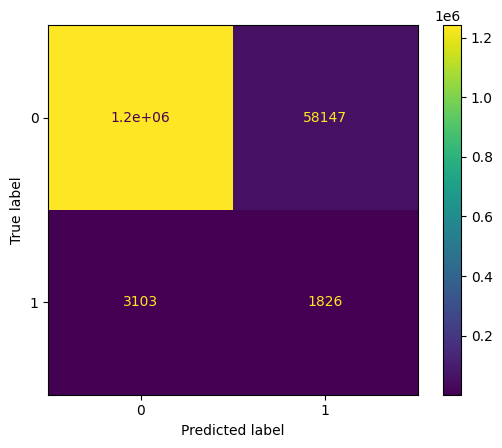

In [36]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

In [37]:
weights = {0: 1, 1: 100}
CatBoost = CatBoostClassifier(iterations=100, depth=6, class_weights=weights, cat_features=cat_features, one_hot_max_size=10, verbose=False)

Train metrics:
Accuracy: 0.9423150825273061
Precision: 0.02981694096960937
Recall: 0.43023930852093145
F1-score: 0.055768919905686144
PR-AUC: 0.05357661708840047

Test metrics:
Accuracy: 0.9523891616557253
Precision: 0.030819446266894108
Recall: 0.3812132278352607
F1-score: 0.057028392794816155
PR-AUC: 0.046648052149189746

Confusion matrix


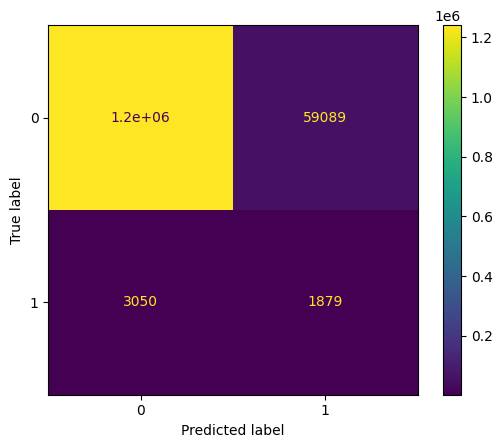

In [38]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

In [39]:
CatBoost.get_feature_importance(type='PredictionValuesChange', prettified=True)

,Feature Id,Importances
0,operaton_amt,15.201089
1,median_amt_pre,8.378782
2,mcc_code,7.488135
3,Hour,6.842818
4,ops_pre,6.543537
5,pos_cd,6.316970
6,std_amt_pre,6.014444
7,mean_amt_pre,5.525785
8,most_common_hour_pre,5.491213
9,event_type_nm,5.170801


In [40]:
weights = {0: 1, 1: 100}
CatBoost = CatBoostClassifier(iterations=100, depth=7, class_weights=weights, cat_features=cat_features, one_hot_max_size=10, verbose=False)

Train metrics:
Accuracy: 0.9423068246035728
Precision: 0.030646178374262326
Recall: 0.44305403255283926
F1-score: 0.05732702919627817
PR-AUC: 0.05730345889666407

Test metrics:
Accuracy: 0.952221364079366
Precision: 0.029940903956651988
Recall: 0.3710691823899371
F1-score: 0.0554108095007271
PR-AUC: 0.04279041997538868

Confusion matrix


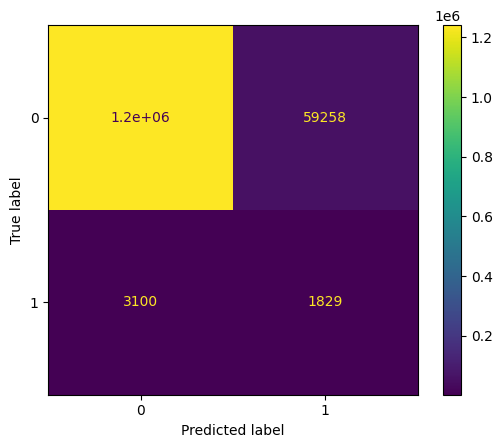

In [41]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

In [42]:
cat_features = [
    'mcc_code', 'event_desc', 'channel_indicator_type',
    'timezone', 'operating_system_type', 'device_system_version',
    'screen_size', 'battery', 'device_info']

In [43]:
weights = {0: 1, 1: 100}
CatBoost = CatBoostClassifier(iterations=100, depth=7, class_weights=weights, cat_features=cat_features, one_hot_max_size=10, verbose=False)

Train metrics:
Accuracy: 0.9437104162385175
Precision: 0.031106256188373715
Recall: 0.43838826893719496
F1-score: 0.05809063609374733
PR-AUC: 0.05726892283554311

Test metrics:
Accuracy: 0.9536671815523804
Precision: 0.031212018906144497
Recall: 0.3751268005680665
F1-score: 0.057629073228505974
PR-AUC: 0.04472511757668324

Confusion matrix


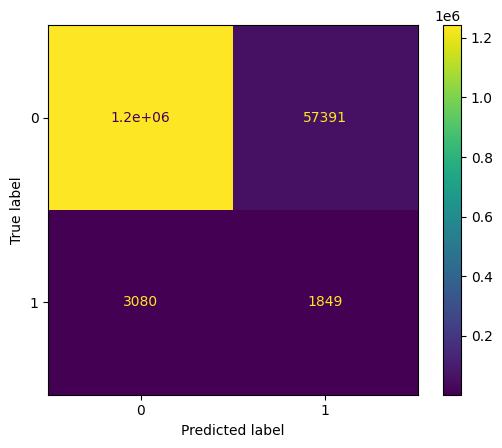

In [44]:
train_models(CatBoost, X_train, X_test, y_train, y_test)